# Build and explore decision tree classifiers on the branchwater search output

In [1]:
# base checkout of workflow directory is here:
#BASE='/Users/t/dev/2025-workflow-core99/'
BASE='/home/ctbrown/scratch3/2025-workflow-core99'

# parquet files from branchwater
#BASE_OUTPUTS=BASE+'/outputs.branchwater'

MIN=90
SCALED=1000
HASH_THRESHOLD=int(20000 / SCALED)

#BASE_OUTPUTS=BASE+f'/outputs.mapping/cds/singlehash.k21/outputs.branchwater.min{MIN}.scaled{SCALED}'
BASE_OUTPUTS=BASE+'/outputs.cds/branchwater.cds3'

In [2]:
import polars as pl
import numpy as np
import sklearn.tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import scipy.spatial.distance
import seaborn as sns
from matplotlib import pyplot as plt

## Load in all the data & filter at HASH_THRESHOLD

In [3]:
dirpath = BASE_OUTPUTS+'/*.parquet'

all_bw_df = pl.scan_parquet(dirpath).collect()
all_bw_df = all_bw_df.with_columns(pl.col("query_name").alias("species"),
                           pl.col("match_name").alias("acc"))
all_bw_df = all_bw_df.select(["species", "acc", "containment", "intersect_hashes"])

before_threshold = set(all_bw_df['species'].unique())

# mimic the Web site search threshold of 0.1
bw_df = all_bw_df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)

after_threshold = set(bw_df['species'].unique())

print('lost:', before_threshold - after_threshold)

lost: set()


In [4]:
print(len(before_threshold))

26


In [5]:
before_threshold = set(bw_df['species'].unique())
before_threshold

{'s__Bariatricus sp004560705',
 's__Bifidobacterium thermacidophilum',
 's__Blautia_A sp945872375',
 's__CAG-269 sp014846485',
 's__CAG-465 sp000433755',
 's__CAG-873 sp016302215',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Gemmiger qucibialis',
 's__Holdemanella porci',
 's__JAFBIX01 sp021531895',
 's__JALFVM01 sp022787145',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Phascolarctobacterium_A succinatutens',
 's__Phascolarctobacterium_A succinatutens_B',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Roseburia inulinivorans',
 's__Ruminococcoides sp902766885',
 's__Ruminococcus_C sp000433635',
 's__SIG351 sp945918795',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__UMGS1225 sp034086705',
 's__Ventricola sp017937505'}

In [6]:
set(all_bw_df['species'].unique())

{'s__Bariatricus sp004560705',
 's__Bifidobacterium thermacidophilum',
 's__Blautia_A sp945872375',
 's__CAG-269 sp014846485',
 's__CAG-465 sp000433755',
 's__CAG-873 sp016302215',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Gemmiger qucibialis',
 's__Holdemanella porci',
 's__JAFBIX01 sp021531895',
 's__JALFVM01 sp022787145',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Phascolarctobacterium_A succinatutens',
 's__Phascolarctobacterium_A succinatutens_B',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Roseburia inulinivorans',
 's__Ruminococcoides sp902766885',
 's__Ruminococcus_C sp000433635',
 's__SIG351 sp945918795',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__UMGS1225 sp034086705',
 's__Ventricola sp017937505'}

## Load in metadata, select for valid accessions and WGS

In [8]:
#metadata_df = pl.scan_parquet('/Users/t/dev/2025-workflow-core99/20241128-metadata.parquet')
metadata_df = pl.scan_parquet('/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet')

metadata_df = metadata_df.select(["acc", "organism", "assay_type", "bioproject"])\
    .filter(pl.col("acc") != "NP")\
    .filter(pl.col("assay_type") == "WGS")

metadata_df = metadata_df.collect()
metadata_df

acc,organism,assay_type,bioproject
str,str,str,str
"""SRR28523869""","""human metagenome""","""WGS""","""PRJNA1095378"""
"""SRR19901137""","""Streptococcus suis""","""WGS""","""PRJNA854064"""
"""SRR24962475""","""Escherichia coli""","""WGS""","""PRJNA982891"""
"""SRR29161330""","""biofilm metagenome""","""WGS""","""PRJNA1116137"""
"""SRR26668739""","""bovine gut metagenome""","""WGS""","""PRJNA1035769"""
…,…,…,…
"""ERR4174288""","""human gut metagenome""","""WGS""","""PRJEB36461"""
"""ERR3160109""","""human gut metagenome""","""WGS""","""PRJEB23292"""
"""ERR2709457""","""human gut metagenome""","""WGS""","""PRJEB27799"""


In [9]:
bw_df = bw_df.join(metadata_df, on="acc", how="inner")
bw_df

species,acc,containment,intersect_hashes,organism,assay_type,bioproject
str,str,f64,i64,str,str,str
"""s__Bariatricus sp004560705""","""ERR2241674""",0.504614,1531,"""metagenome""","""WGS""","""PRJEB22062"""
"""s__Bariatricus sp004560705""","""ERR2241669""",0.504614,1531,"""metagenome""","""WGS""","""PRJEB22062"""
"""s__Bariatricus sp004560705""","""SRR11185229""",0.488134,1481,"""pig gut metagenome""","""WGS""","""PRJNA526405"""
"""s__Bariatricus sp004560705""","""SRR9866666""",0.479235,1454,"""Lawsonia intracellularis""","""WGS""","""PRJNA554776"""
"""s__Bariatricus sp004560705""","""SRR11185232""",0.478906,1453,"""pig gut metagenome""","""WGS""","""PRJNA526405"""
…,…,…,…,…,…,…
"""s__Ventricola sp017937505""","""SRR8881010""",0.036298,20,"""wetland metagenome""","""WGS""","""PRJNA531780"""
"""s__Ventricola sp017937505""","""SRR29660186""",0.036298,20,"""rhizosphere metagenome""","""WGS""","""PRJNA1128034"""
"""s__Ventricola sp017937505""","""SRR12277022""",0.036298,20,"""gut metagenome""","""WGS""","""PRJNA647269"""


In [10]:
bw_df['organism'].value_counts().sort(by='count', descending=True)

organism,count
str,u32
"""human gut metagenome""",287859
"""pig gut metagenome""",101040
"""gut metagenome""",81355
"""metagenome""",64150
"""soil metagenome""",42500
…,…
"""Pseudomonas asiatica""",1
"""Candidatus Thiodiazotropha sp.…",1
"""Dermacentor sinicus""",1


## Build a new dataframe, 'simpleorg', that is just three values: human, pig, other.

In [11]:
rename_df = []
for organism in bw_df['organism'].unique().to_list():
    simpleorg = 'unknown'
    if organism:
        organism = organism.lower()
        for kw in ['human', 'homo']:
            if kw in organism.lower():
                simpleorg = 'human'
                break
        for kw in ['pig', 'sus', 'scrofa']:
            if kw in organism.lower():
                simpleorg = 'pig'
                break
    rename_df.append(dict(organism=organism, simpleorg=simpleorg))

rename_df = pl.DataFrame(rename_df)
rename_df['simpleorg'].value_counts().sort(by='count', descending=True)


simpleorg,count
str,u32
"""unknown""",624
"""human""",23
"""pig""",10


In [12]:
rename_df

organism,simpleorg
str,str
"""biofilter metagenome""","""unknown"""
"""subdoligranulum sp. ds40""","""unknown"""
"""cryptotympana atrata""","""unknown"""
"""graminella nigrifrons""","""unknown"""
"""corynebacterium argentoratense""","""unknown"""
…,…
"""soil metagenome""","""unknown"""
"""muntiacus reevesi""","""unknown"""
"""canis lupus familiaris""","""unknown"""


## Add a new column, `simpleorg`, to the branchwater output.

In [13]:
bw_df

species,acc,containment,intersect_hashes,organism,assay_type,bioproject
str,str,f64,i64,str,str,str
"""s__Bariatricus sp004560705""","""ERR2241674""",0.504614,1531,"""metagenome""","""WGS""","""PRJEB22062"""
"""s__Bariatricus sp004560705""","""ERR2241669""",0.504614,1531,"""metagenome""","""WGS""","""PRJEB22062"""
"""s__Bariatricus sp004560705""","""SRR11185229""",0.488134,1481,"""pig gut metagenome""","""WGS""","""PRJNA526405"""
"""s__Bariatricus sp004560705""","""SRR9866666""",0.479235,1454,"""Lawsonia intracellularis""","""WGS""","""PRJNA554776"""
"""s__Bariatricus sp004560705""","""SRR11185232""",0.478906,1453,"""pig gut metagenome""","""WGS""","""PRJNA526405"""
…,…,…,…,…,…,…
"""s__Ventricola sp017937505""","""SRR8881010""",0.036298,20,"""wetland metagenome""","""WGS""","""PRJNA531780"""
"""s__Ventricola sp017937505""","""SRR29660186""",0.036298,20,"""rhizosphere metagenome""","""WGS""","""PRJNA1128034"""
"""s__Ventricola sp017937505""","""SRR12277022""",0.036298,20,"""gut metagenome""","""WGS""","""PRJNA647269"""


In [14]:
# add a new column with a simplified organism
bw_df = bw_df.join(rename_df, on='organism', how='inner', coalesce=True).select(['acc', 'organism', 'species', 'simpleorg', 'bioproject'])
bw_df.select(['acc', 'simpleorg']).unique()['simpleorg'].value_counts()


simpleorg,count
str,u32
"""unknown""",94610
"""human""",137152
"""pig""",7116


In [15]:
bw_df

acc,organism,species,simpleorg,bioproject
str,str,str,str,str
"""ERR2241674""","""metagenome""","""s__Bariatricus sp004560705""","""unknown""","""PRJEB22062"""
"""ERR2241669""","""metagenome""","""s__Bariatricus sp004560705""","""unknown""","""PRJEB22062"""
"""SRR11185229""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA526405"""
"""SRR11185232""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA526405"""
"""SRR8960383""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA526405"""
…,…,…,…,…
"""SRR8881010""","""wetland metagenome""","""s__Ventricola sp017937505""","""unknown""","""PRJNA531780"""
"""SRR29660186""","""rhizosphere metagenome""","""s__Ventricola sp017937505""","""unknown""","""PRJNA1128034"""
"""SRR12277022""","""gut metagenome""","""s__Ventricola sp017937505""","""unknown""","""PRJNA647269"""


## Set up for classifier work - `make_matrices`

Create a function that takes a dataframe with `acc`, `species`, and `simpleorg`, and builds numpy matrices
suitable for scikit-learn classifers.

In [16]:
def make_matrices(df):
    acc_df = df['acc'].unique().to_frame().sort(by='acc').with_row_index(name='acc_index')
    species_df = df['species'].unique().to_frame().sort(by='species').with_row_index(name='species_index')
    org_df = df['simpleorg'].unique().to_frame().sort(by='simpleorg').with_row_index(name='org_index')

    df = df.join(org_df, on='simpleorg', how='left')
    df = df.join(acc_df, on='acc', how='left')
    df = df.join(species_df, on='species', how='left')

    obs = np.zeros((len(acc_df), len(species_df)))
    target = np.zeros((len(acc_df)))

    for row in df.iter_rows(named=True):
        acc_id = row["acc_index"]
        org_id = row["org_index"]
        species_id = row["species_index"]

        obs[acc_id, species_id] = 1
        target[acc_id] = org_id

    print(f'observations matrix shape is: {obs.shape}')

    return df, obs, target


### Build another function that returns a distance matrix between the columns

Default metric: cosine; support others such as Jaccard.

In [17]:
def make_col_dist(mat, *, metric='cosine'):
    n_col = mat.shape[1]
    col_dist = np.ones((n_col, n_col))

    distf = getattr(scipy.spatial.distance, metric)
    for i in range(n_col):
        for j in range(i):
            d = distf(mat[:,i], mat[:,j])
            col_dist[i, j] = d
            col_dist[j, i] = d
        col_dist[i, i] = 0
    
    col_dist = 1 - col_dist
    return col_dist

## Explore frequencies of & correlations between species metrics in datasets of different types

### Human + pig only

In [18]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
hp_df, hp_obs, hp_target = make_matrices(human_pig_only)
print(f'made matrices for {len(human_pig_only)} rows, {hp_obs.shape[1]} species')

observations matrix shape is: (144268, 26)
made matrices for 432272 rows, 26 species


In [19]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
hp_df, hp_obs, hp_target = make_matrices(human_pig_only)

hp_col_dist = make_col_dist(hp_obs)
hp_labels = hp_df.select(['species_index', 'species']).unique().sort(by='species_index')['species'].to_list()
sns.clustermap(hp_col_dist, yticklabels=hp_labels)
plt.title(f"species correlation across {hp_df['acc'].n_unique()} human/pig metagenomes")

observations matrix shape is: (144268, 26)


KeyboardInterrupt: 

### Pig only

observations matrix shape is: (7116, 26)


Text(0.5, 1.0, 'species correlation across 7116 pig metagenomes')

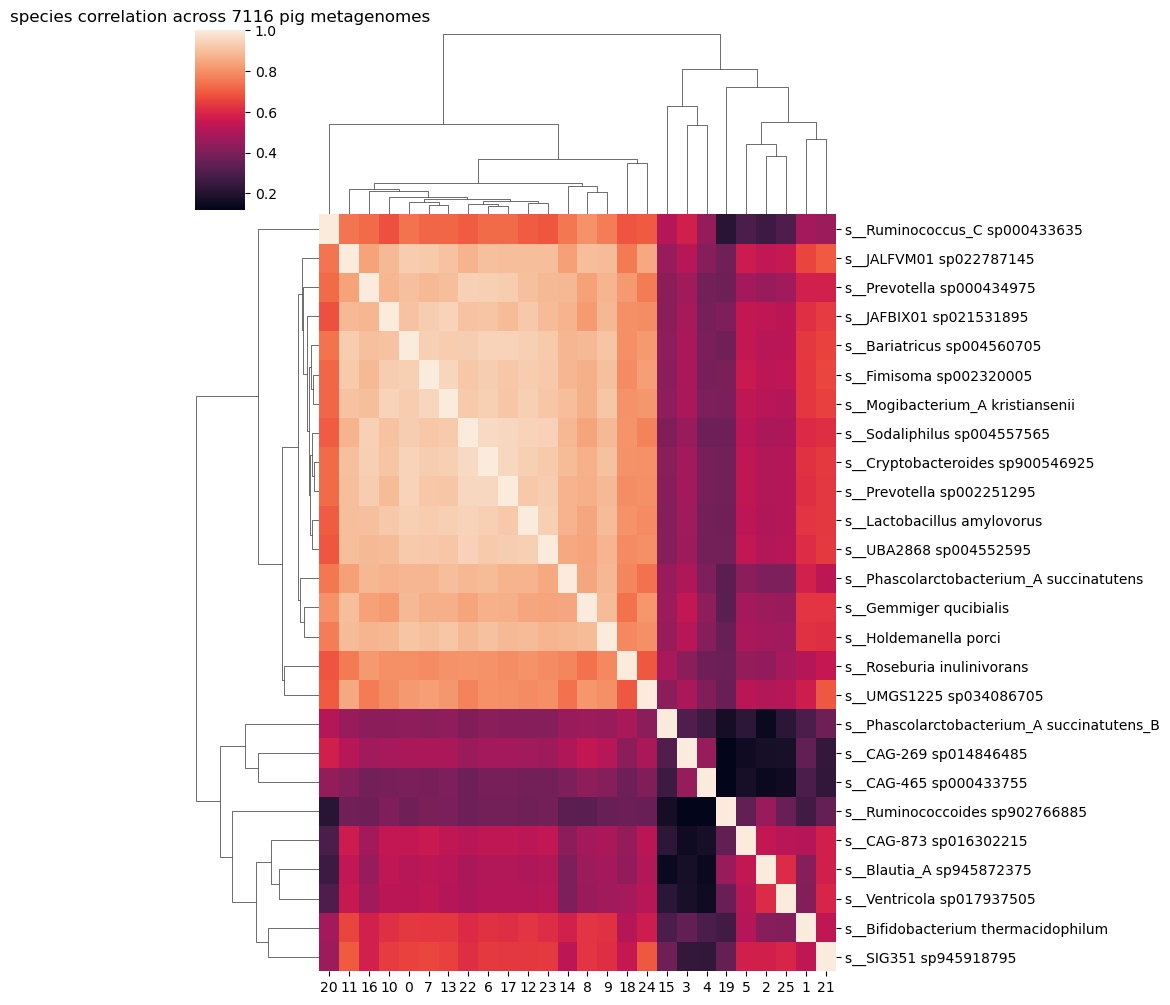

In [20]:
pig_only = bw_df.filter(pl.col("simpleorg") == "pig")
pig_df, pig_obs, pig_target = make_matrices(pig_only)

pig_col_dist = make_col_dist(pig_obs)
pig_labels = pig_df.select(['species_index', 'species']).unique().sort(by='species_index')['species'].to_list()
sns.clustermap(pig_col_dist, yticklabels=pig_labels)
plt.title(f"species correlation across {pig_df['acc'].n_unique()} pig metagenomes")

### Frequencies of species in pig

In [21]:
total_accs = pig_df['acc'].n_unique()
freq_pig_df = pig_df.group_by('species').agg((pl.col("acc").len() / total_accs).alias("pig_freq")).sort(by='pig_freq', descending=True)

with pl.Config(tbl_rows=-1):
    print(freq_pig_df)

shape: (26, 2)
┌─────────────────────────────────┬──────────┐
│ species                         ┆ pig_freq │
│ ---                             ┆ ---      │
│ str                             ┆ f64      │
╞═════════════════════════════════╪══════════╡
│ s__Sodaliphilus sp004557565     ┆ 0.956436 │
│ s__Lactobacillus amylovorus     ┆ 0.897976 │
│ s__UBA2868 sp004552595          ┆ 0.886875 │
│ s__Cryptobacteroides sp9005469… ┆ 0.884345 │
│ s__Prevotella sp002251295       ┆ 0.883924 │
│ s__Prevotella sp000434975       ┆ 0.84851  │
│ s__Bariatricus sp004560705      ┆ 0.841906 │
│ s__Mogibacterium_A kristiansen… ┆ 0.817454 │
│ s__Fimisoma sp002320005         ┆ 0.812395 │
│ s__JAFBIX01 sp021531895         ┆ 0.802136 │
│ s__Holdemanella porci           ┆ 0.750141 │
│ s__Phascolarctobacterium_A suc… ┆ 0.746908 │
│ s__JALFVM01 sp022787145         ┆ 0.729202 │
│ s__Gemmiger qucibialis          ┆ 0.677066 │
│ s__Roseburia inulinivorans      ┆ 0.631816 │
│ s__UMGS1225 sp034086705         ┆ 0.567032 

### Human only

In [ ]:
human_only = bw_df.filter(pl.col("simpleorg") == "human")
human_df, human_obs, human_target = make_matrices(human_only)

human_col_dist = make_col_dist(human_obs)
human_labels = human_df.select(['species_index', 'species']).unique().sort(by='species_index')['species'].to_list()

sns.clustermap(human_col_dist, yticklabels=human_labels)

plt.title(f"species correlation across {human_df['acc'].n_unique()} human metagenomes")

### Frequencies of species in human only

In [ ]:
total_accs = human_df['acc'].n_unique()
freq_human_df = human_df.group_by('species').agg((pl.col("acc").len() / total_accs).alias("human_freq")).sort(by='human_freq', descending=True)

with pl.Config(tbl_rows=-1):
    print(freq_human_df)

## Frequencies of species in pig _compared_ to human

In [ ]:
with pl.Config(tbl_rows=-1):
    print(freq_human_df.join(freq_pig_df, on='species'))

## 6-Fold Cross Validation approach

Run 6 different splits of the data; train on 1/6 of the data and test on the other 5/6s of the data, and then repeat that for each of the 6 splits.

In [ ]:
kf = StratifiedKFold(n_splits=6)

accuracies = []
i = 1
for train_sub, test_sub in kf.split(hp_obs, hp_target):
    dt = DecisionTreeClassifier(random_state=42)
    tree = dt.fit(hp_obs[train_sub], hp_target[train_sub])
    pred = tree.predict(hp_obs[test_sub])

    accuracy = balanced_accuracy_score(hp_target[test_sub], pred, adjusted=True)
    accuracies.append(accuracy)
    print(f"iteration {i}: accuracy {accuracy:.3f}")
    print('xxx', roc_auc_score(hp_target[test_sub], pred))
    i += 1

print(f"mean accuracy across {i-1} splits: {np.mean(accuracies):.3f}")

## What do we after 6-fold cross validation?

This approach lets us check to see that, in general, the performance of any classifer trained on this data will be pretty good - independent of which set of data we use.

Now, to train the best possible classifier for _future_ use, we will use all the data to train:

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
tree = dt.fit(hp_obs, hp_target)
pred = tree.predict(hp_obs)

accuracy = balanced_accuracy_score(hp_target, pred, adjusted=True)

print(f"full classifier: accuracy {accuracy:.3f}")
print(f"full classifier: ROC AUC score: {roc_auc_score(hp_target, pred):.3f}")


## What do we do with the full classifier now??

Now we can go back to the original data - not just the human/pig subset, but the one with unknowns. (Or, potentially, new data sets.)

The only thing we need to be careful about is to encode new observations using the species indexes that match the trained classifier, as well as the organism indexes (0 pig, 1 human). Let's extract those:

In [ ]:
species_index_df = hp_df.select(['species_index', 'species']).unique()
species_index_df

In [ ]:
org_df = hp_df.select(['org_index', 'simpleorg']).unique()
org_df

### Classify "other"/unknown

Now, let's take some of some of the data we didn't touch from the original bw_df, and encode and classify it: 

In [ ]:
def make_obs_matrix(df, species_df):
    # need a new accession mapping
    acc_df = df['acc'].unique().to_frame().sort(by='acc').with_row_index(name='acc_index')

    # construct new internal data frame, populate
    df = df.join(acc_df, on='acc', how='left')
    df = df.join(species_df, on='species', how='left')

    obs = np.zeros((len(acc_df), len(species_df)))

    for row in df.iter_rows(named=True):
        acc_id = row["acc_index"]
        species_id = row["species_index"]

        obs[acc_id, species_id] = 1

    print(f'observations matrix shape is: {obs.shape}')

    return df, obs


In [ ]:
unknown_only_df = bw_df.filter(pl.col("simpleorg") == "unknown")
unk_df, unk_obs = make_obs_matrix(unknown_only_df, species_index_df)

In [ ]:
unknown_pred = tree.predict(unk_obs)
unknown_pred

## Predictions are great and all but...

Great! Lots of predictions 😭 . What do we do with them??

Let's merge the predictions back into the unknown df.

In [ ]:
unk_pred_df = []
for (row_n, predicted_org) in enumerate(unknown_pred):
    unk_pred_df.append(dict(acc_index=row_n, org_index=int(predicted_org)))
unk_pred_df = pl.DataFrame(unk_pred_df).join(org_df, on='org_index', how='left')
unk_pred_df = unk_pred_df.with_columns(pl.col("simpleorg").alias("predicted_org"))

# add accessions in (?)
unk_acc_df = unk_df.select(["acc", "acc_index"]).unique()

unk_pred_df = unk_pred_df.join(unk_acc_df, on='acc_index', how='left').select(["acc", "predicted_org"])
unk_pred_df

In [ ]:
unk_pred_df["predicted_org"].value_counts().sort(by='count', descending=True)

## OK! We have our predictions... did this actually work?

In [ ]:
bw_df

In [ ]:
curated_df = pl.read_csv('../inputs.branchwater/manual_curation_bioprj.done.2025-12-22.csv')
curated_df = curated_df.join(bw_df, on='bioproject', how='inner').select(['acc', 'manual_cur'])
unk_pred_df = unk_pred_df.join(curated_df, on='acc').select(['acc', 'predicted_org', 'manual_cur'])


In [ ]:
# sample 5 randomly
unk_pred_df.sample(n=5)

In [ ]:
# sample 5 predicted as pig
unk_pred_df.filter(pl.col("predicted_org") == "pig").sample(n=5)

In [ ]:
# sample 5 predicted as human
unk_pred_df.filter(pl.col("predicted_org") == "human").sample(n=5)

# What features are most important for good classification?

First, let's get the feature importances.

In [ ]:
importances_df = []
for (species_index, importance) in enumerate(tree.feature_importances_):
    d = dict(species_index=species_index, importance=importance)
    importances_df.append(d)

importances_df = pl.DataFrame(importances_df)
importances_df = importances_df.join(species_index_df, on='species_index', how='left')
importances_df = importances_df.sort(by='importance', descending=True)

with pl.Config(tbl_rows=-1, tbl_width_chars=-1, fmt_str_lengths=50):
    print(importances_df.sort(by='importance', descending=True).head(15))

In [ ]:
with pl.Config(tbl_rows=-1, tbl_width_chars=-1, fmt_str_lengths=50):
    print(importances_df.sort(by='importance', descending=False).head(15))
    

#### Now let's rebuild the classifier after removing each species, and see how well it does...

In [ ]:
species_in_order = importances_df['species'].to_list()
species_in_order

In [ ]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
species_to_rm = list(species_in_order)

remove_df = human_pig_only
while len(species_to_rm) >= 2:
    rm_species = species_to_rm.pop(0)
    print(f'removing {rm_species} too')
    if len(species_to_rm) == 1:
        print('left:', species_to_rm[0])

    remove_df = remove_df.filter(pl.col("species") != rm_species)
    augmented_df, rm_obs, rm_target = make_matrices(remove_df)

    dt = DecisionTreeClassifier(random_state=42)
    tree = dt.fit(rm_obs, rm_target)
    pred = tree.predict(rm_obs)

    accuracy = balanced_accuracy_score(rm_target, pred, adjusted=True)
    print(f"classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")
    print('---')

## Remove in reverse order of importance

In [ ]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
species_to_rm = list(reversed(species_in_order))

remove_df = human_pig_only
while len(species_to_rm) >= 2:
    rm_species = species_to_rm.pop(0)
    print(f'removing {rm_species} too')

    remove_df = remove_df.filter(pl.col("species") != rm_species)
    augmented_df, rm_obs, rm_target = make_matrices(remove_df)

    dt = DecisionTreeClassifier(random_state=42)
    tree = dt.fit(rm_obs, rm_target)
    pred = tree.predict(rm_obs)

    accuracy = balanced_accuracy_score(rm_target, pred, adjusted=True)
    print(f"classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")
    print('---')

### Partition out the species into our "golden 4" and "the rest"

In [ ]:
human_pig_only['species'].unique().to_list()

In [ ]:
SUB_SPECIES=('s__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
             's__Prevotella sp000434975',
             's__Holdemanella porci',
             's__Bariatricus sp004560705',
             's__Fimisoma sp002320005',
             's__Gemmiger qucibialis',
             's__JAFBIX01 sp021531895',
             's__JALFVM01 sp022787145',
             's__Lactobacillus amylovorus',
             's__Roseburia inulinivorans',
             's__Sodaliphilus sp004557565',
             's__UBA2868 sp004552595',
)
SUB_SPECIES2=(
             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
#             's__Prevotella sp000434975',
#             's__Holdemanella porci',
)
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
remove_df = human_pig_only.filter(pl.col("species").is_in(set(SUB_SPECIES2)))
assert len(remove_df)

augmented_df, rm_obs, rm_target = make_matrices(remove_df)

dt = DecisionTreeClassifier(random_state=42)
tree = dt.fit(rm_obs, rm_target)
pred = tree.predict(rm_obs)

accuracy = balanced_accuracy_score(rm_target, pred, adjusted=True)
print(f"classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")

In [ ]:
text_representation = sklearn.tree.export_text(tree)
print(text_representation)

In [ ]:
species_df = augmented_df.select(['species_index', 'species']).unique()

for n in (0, 3):
    species = species_df.filter(pl.col('species_index') == n)['species'].to_list()[0]
    print(f'feature {n} is {species}')

In [ ]:
def py_predict(features):
    if features[0] and features[3]:
        is_pig = 1
    else:
        is_pig = 0

    return is_pig

my_pred = np.zeros((rm_obs.shape[0],))

for i in range(my_pred.shape[0]):
    obs_vector = rm_obs[i,:]
    my_pred[i] = py_predict(obs_vector)

accuracy = balanced_accuracy_score(rm_target, my_pred, adjusted=True)
print(f"python-custom-func classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")

In [ ]:
SUB_SPECIES=('s__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
             's__Prevotella sp000434975',
             's__Holdemanella porci',
             's__Bariatricus sp004560705',
             's__Fimisoma sp002320005',
             's__Gemmiger qucibialis',
             's__JAFBIX01 sp021531895',
             's__JALFVM01 sp022787145',
             's__Lactobacillus amylovorus',
             's__Roseburia inulinivorans',
             's__Sodaliphilus sp004557565',
             's__UBA2868 sp004552595',
)
SUB_SPECIES2=(
             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
#             's__Prevotella sp000434975',
#             's__Holdemanella porci',
)
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
remove2_df = human_pig_only.filter(~pl.col("species").is_in(set(SUB_SPECIES2)))
assert len(remove2_df)

augmented2_df, rm2_obs, rm2_target = make_matrices(remove2_df)

dt = DecisionTreeClassifier(random_state=42)
tree = dt.fit(rm2_obs, rm2_target)
pred = tree.predict(rm2_obs)

accuracy = balanced_accuracy_score(rm2_target, pred)
print(f"classifier accuracy with {remove2_df['species'].n_unique()} species is: {accuracy:.3f}")